# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Tazkiya Aulia Rachman
- **Email:** rachmantazkiya@gmail.com
- **ID Dicoding:** [Input Username]

## Menentukan Pertanyaan Bisnis

1. Bagaimana perubahan jumlah penyewaan sepeda berdasarkan siklus waktu (jam, hari dalam seminggu, bulan, dan tahun)?
2. Sejauh mana faktor lingkungan (musim dan kondisi cuaca) memengaruhi total volume penyewaan sepeda?
3. Bagaimana perbandingan karakteristik dan tren antara pengguna Casual dan Registered dalam melakukan penyewaan?
4. Apakah terdapat perbedaan signifikan pada pola penyewaan antara hari kerja (workingday) dibandingkan dengan hari libur (holiday/weekend)?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")


Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.


In [3]:
hour_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lakshmi25npathi/bike-sharing-dataset",
  "hour.csv"
)

hour_df.head()

Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
day_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lakshmi25npathi/bike-sharing-dataset",
  "day.csv"
)

day_df.head()

Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Assessing Data

1. Assessing tabel hour.csv

In [5]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [7]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [8]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


2. Assessing tabel day.csv

In [9]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [10]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [11]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [12]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
dari kedua tabel tersebut tidak ditemukan missing value dan data duplikat

### Cleaning Data

sehingga, pada proses cleaning akan dilakukan penyesuaian tipe data, nama kolom serta value sesuai kebutuhan agar mudah dipahami

In [13]:
#mengubah nama kolom agar mudah dipahami
hour_df.rename(columns={
    'hr': 'hour',
    'yr': 'year',
    'mnth': 'month',
    'dteday': 'date',
    'cnt': 'total_rentals',
    'casual': 'casual_users',
    'registered': 'registered_users'
}, inplace=True)

day_df.rename(columns={
    'mnth': 'month',
    'yr': 'year',
    'dteday': 'date',
    'cnt': 'total_rentals',
    'casual': 'casual_users',
    'registered': 'registered_users'
}, inplace=True)

In [14]:
hour_df[['season', 'year', 'month', 'weekday','weathersit']] = hour_df[['season', 'year', 'month', 'weekday', 'weathersit']].apply(lambda x: x.astype('category'))
hour_df['date'] = hour_df['date'].astype('datetime64[ns]')

day_df[['season', 'year', 'month', 'weekday','weathersit']] = day_df[['season', 'year', 'month', 'weekday', 'weathersit']].apply(lambda x: x.astype('category'))
day_df['date'] = day_df['date'].astype('datetime64[ns]')

hour_df.info()
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   instant           17379 non-null  int64         
 1   date              17379 non-null  datetime64[ns]
 2   season            17379 non-null  category      
 3   year              17379 non-null  category      
 4   month             17379 non-null  category      
 5   hour              17379 non-null  int64         
 6   holiday           17379 non-null  int64         
 7   weekday           17379 non-null  category      
 8   workingday        17379 non-null  int64         
 9   weathersit        17379 non-null  category      
 10  temp              17379 non-null  float64       
 11  atemp             17379 non-null  float64       
 12  hum               17379 non-null  float64       
 13  windspeed         17379 non-null  float64       
 14  casual_users      1737

In [15]:
#mengubah value pada kolom sesuai dengan deskripsi datasetagar mudah dipahami
replacements = {
    'season': {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'},
    'year': {0: 2011, 1: 2012},
    'month' : {1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni', 7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'},
    'weekday': {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'},
    'weathersit': {1: 'Clear/Partly Cloudy', 2: 'Misty/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'},
}

for col, mapping in replacements.items():
    if col in hour_df.columns:
        hour_df[col] = hour_df[col].map(mapping)


In [16]:
hour_df.head()

,instant,date,season,year,month,hour,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual_users,registered_users,total_rentals
0,1,2011-01-01,Spring,2011,Januari,0,0,Saturday,0,Clear/Partly Cloudy,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,Januari,1,0,Saturday,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,Januari,2,0,Saturday,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,Januari,3,0,Saturday,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,Januari,4,0,Saturday,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,0,1,1


In [17]:
#mengubah value pada kolom sesuai dengan deskripsi datasetagar mudah dipahami
replacements = {
    'season': {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'},
    'year': {0: 2011, 1: 2012},
    'month' : {1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni', 7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'},
    'weekday': {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'},
    'weathersit': {1: 'Clear/Partly Cloudy', 2: 'Misty/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'},
}

for col, mapping in replacements.items():
    if col in day_df.columns:
        day_df[col] = day_df[col].map(mapping)


In [18]:
day_df.head()

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual_users,registered_users,total_rentals
0,1,2011-01-01,Spring,2011,Januari,0,Saturday,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,Januari,0,Sunday,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,Januari,0,Monday,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,Januari,0,Tuesday,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,Januari,0,Wednesday,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**

dari proses cleaning data, sudah dilakukan
1. perubahan tipe data int pada beberapa kolom sesuai kebutuhan
2. perubahan nama kolom agar lebih mudah dipahami
3. mengubah value kolom yang menggunakan kategori angka menjadi deskripsi sebenarnya

## Exploratory Data Analysis (EDA)

### Explore hour_df

In [19]:
hour_df.sample(5)

,instant,date,season,year,month,hour,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual_users,registered_users,total_rentals
17287,17288,2012-12-28,Spring,2012,Desember,4,0,Friday,1,Misty/Cloudy,0.24,0.2576,0.60,0.1045,0,4,4
5210,5211,2011-08-10,Fall,2011,Agustus,0,0,Wednesday,1,Clear/Partly Cloudy,0.74,0.6667,0.51,0.2239,19,18,37
2960,2961,2011-05-08,Summer,2011,Mei,6,0,Sunday,0,Misty/Cloudy,0.44,0.4394,0.82,0.0000,2,4,6
13731,13732,2012-07-31,Fall,2012,Juli,8,0,Tuesday,1,Clear/Partly Cloudy,0.70,0.6667,0.79,0.1343,30,730,760
3481,3482,2011-05-29,Summer,2011,Mei,23,0,Sunday,0,Clear/Partly Cloudy,0.66,0.5909,0.89,0.1642,48,87,135


In [20]:
hour_df.describe(include="all")

,instant,date,season,year,month,hour,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual_users,registered_users,total_rentals
count,17379.0000,17379,17379,17379.0,17379,17379.000000,17379.000000,17379,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,2.0,12,NaN,NaN,7,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012.0,Juli,NaN,NaN,Saturday,NaN,Clear/Partly Cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,8734.0,1488,NaN,NaN,2512,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,11.546752,0.028770,NaN,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,6.000000,0.000000,NaN,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,12.000000,0.000000,NaN,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,18.000000,0.000000,NaN,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,23.000000,1.000000,NaN,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [21]:
#jumlah penyewaan berdasarkan jam
hour_df.groupby(by="hour", observed=True).agg({
    "total_rentals": ["sum"]
})

,total_rentals
,sum
hour,
0,39130
1,24164
2,16352
3,8174
4,4428
5,14261
6,55132
7,154171


In [22]:
#total penyewaan berdasarkan jenis user pada tahun 2011 dan 2012
hour_df.groupby(by="year", observed=True).agg({
    "casual_users": ["sum"],
    "registered_users": ["sum"]
})

,casual_users,registered_users
,sum,sum
year,,
2011,247252,995851
2012,372765,1676811


In [23]:
#total penyewaan berdasarkan cuaca (weathersit)
hour_df.groupby(by="weathersit", observed=True).total_rentals.sum().reset_index()

,weathersit,total_rentals
0,Clear/Partly Cloudy,2338173
1,Misty/Cloudy,795952
2,Light Rain/Snow,158331
3,Heavy Rain/Snow,223


**Insight:**
Pada tabel hour, dilakukan eksplorasi untuk melihat data yang diinginkan.
Di mana didapatkan data sbb:
1. penyewaan terbanyak terjadi pada busy hour (7-9 & 17-19)
2. total casual user pada tahun 2011 yaitu 247252	sedangkan di 2012 sebanyak 372765. Kemudian registered user di tahun 2011 yaitu 995851 sedangkan di 2012 1676811
3. penyewaan terbanyak terjadi ketika cuaca Clear/Partly Cloudy

### Explore day_df

In [24]:
day_df.sample(5)

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual_users,registered_users,total_rentals
260,261,2011-09-18,Fall,2011,September,0,Sunday,0,Clear/Partly Cloudy,0.507500,0.490537,0.695000,0.178483,1353,2921,4274
11,12,2011-01-12,Spring,2011,Januari,0,Wednesday,1,Clear/Partly Cloudy,0.172727,0.160473,0.599545,0.304627,25,1137,1162
548,549,2012-07-02,Fall,2012,Juli,0,Monday,1,Clear/Partly Cloudy,0.781667,0.702038,0.447083,0.195267,904,5323,6227
208,209,2011-07-28,Fall,2011,Juli,0,Thursday,1,Clear/Partly Cloudy,0.779167,0.739900,0.583333,0.178479,606,3784,4390
443,444,2012-03-19,Spring,2012,Maret,0,Monday,1,Clear/Partly Cloudy,0.545000,0.532821,0.728750,0.162317,982,5171,6153


In [25]:
#total penyewaan berdasarkan musim (season)
day_df.groupby(by="season", observed=True).total_rentals.sum().reset_index()

,season,total_rentals
0,Spring,471348
1,Summer,918589
2,Fall,1061129
3,Winter,841613


In [26]:
#total penyewaan berdasarkan hari kerja
#if day is neither weekend nor holiday is 1, otherwise is 0
day_df.groupby(day_df['workingday'].map({0: 'Weekend/Holiday', 1: 'Working Day'}))['total_rentals'].sum().reset_index()

,workingday,total_rentals
0,Weekend/Holiday,1000269
1,Working Day,2292410


In [27]:
#total penyewaan setiap bulannya
day_df.groupby(by=["year", "month"], observed=True).agg({
    "total_rentals": "sum"
}).reset_index()

,year,month,total_rentals
0,2011,Januari,38189
1,2011,Februari,48215
2,2011,Maret,64045
3,2011,April,94870
4,2011,Mei,135821
5,2011,Juni,143512
6,2011,Juli,141341
7,2011,Agustus,136691
8,2011,September,127418
9,2011,Oktober,123511


**Insight:**
Pada tabel hour, dilakukan eksplorasi untuk melihat data yang diinginkan.
Di mana didapatkan data sbb:
1. penyewaan terbanyak terjadi saat musim Fall/gugur
2. penyewaan terbanyak terjadi saat workingday (hari kerja)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perubahan jumlah penyewaan sepeda berdasarkan siklus waktu (jam, hari dalam seminggu, bulan, dan tahun)?

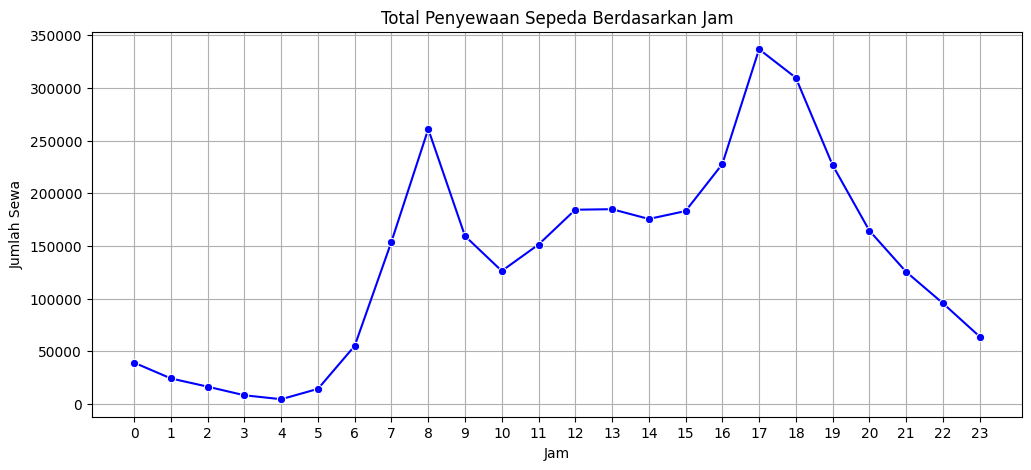

In [28]:
#perubahan jumlah penyewaan berdasarkan jam
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=hour_df,
    x='hour',
    y='total_rentals',
    estimator='sum',
    errorbar=None,
    color='blue',
    marker='o')
plt.title('Total Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Sewa')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


**Insight:** dari hasil explorasi yang hanya bisa dilihat dengan angka pada tabel, namun pada grafik visualisasi total penyewaan pada setiap jamnya bisa dilihat relatif lebih tinggi pada jam sibuk (7-9 & 17-19)

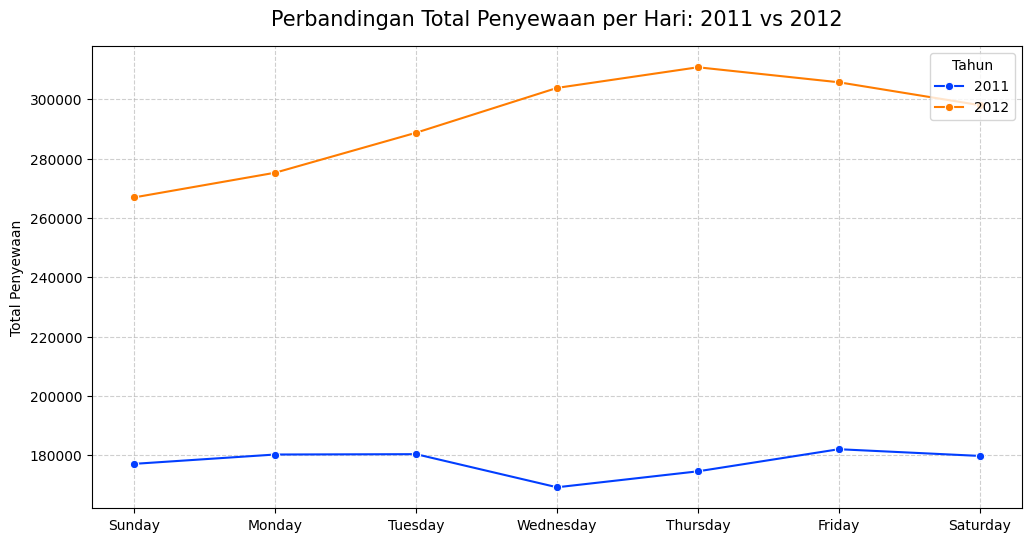

In [29]:
#perubahan jumlah penyewaan berdasarkan hari
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=day_df,
    x='weekday',
    y='total_rentals',
    hue='year',
    estimator='sum',
    errorbar=None,
    marker='o',
    palette='bright'
)

plt.title('Perbandingan Total Penyewaan per Hari: 2011 vs 2012', fontsize=15, pad=15)
plt.xlabel(None)
plt.ylabel('Total Penyewaan')
plt.legend(title='Tahun', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Insight:**
di tahun 2011 penyewaan sepeda setiap harinya jauh lebih rendah dibanding tahun 2012

In [30]:
day_df.groupby(['year', 'month'], observed=True)['total_rentals'].sum().reset_index()

,year,month,total_rentals
0,2011,Januari,38189
1,2011,Februari,48215
2,2011,Maret,64045
3,2011,April,94870
4,2011,Mei,135821
5,2011,Juni,143512
6,2011,Juli,141341
7,2011,Agustus,136691
8,2011,September,127418
9,2011,Oktober,123511


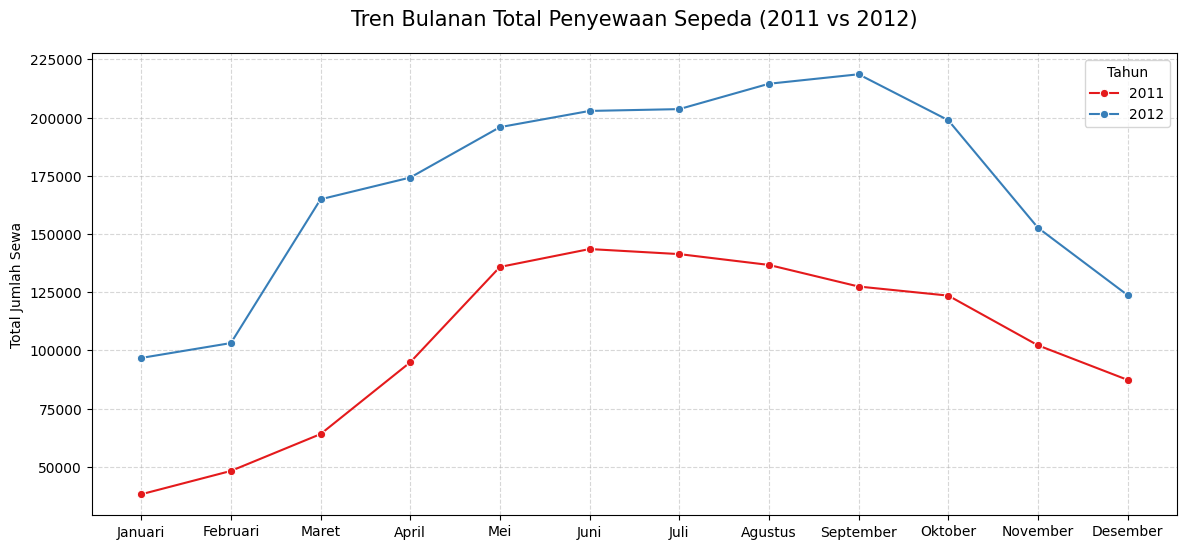

In [31]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=day_df,
    x='month',
    y='total_rentals',
    hue='year',
    estimator='sum',
    errorbar=None,
    marker='o',
    palette='Set1'
)

plt.title('Tren Bulanan Total Penyewaan Sepeda (2011 vs 2012)', fontsize=15, pad=20)
plt.xlabel(None)
plt.ylabel('Total Jumlah Sewa')
plt.legend(title='Tahun')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:** penyewaan yang terjadi di tahun 2011 lebih rendah dibandingkan dengan tahun 2012

In [32]:
day_df.groupby(by=["year"], observed=True).agg({
    "total_rentals": "sum"
}).reset_index()

,year,total_rentals
0,2011,1243103
1,2012,2049576


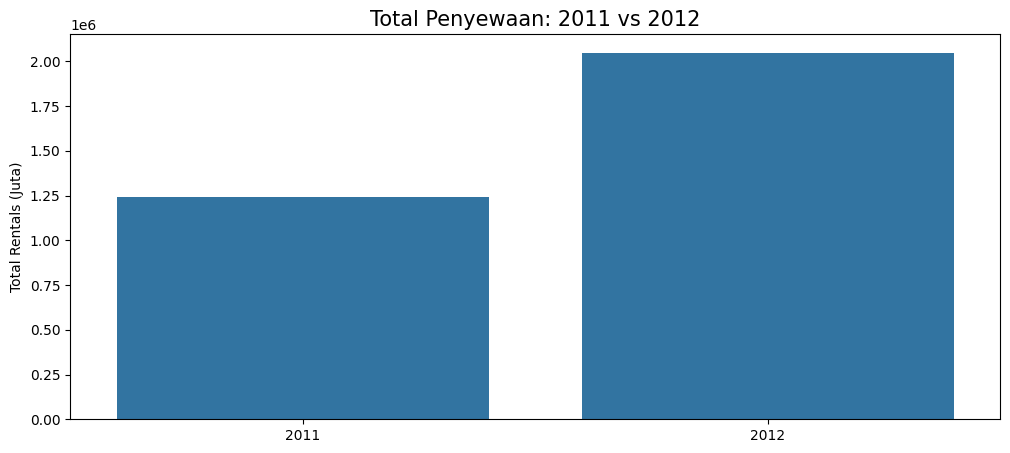

In [33]:
#total penyewaan pada tahun 2011 dan 2012
plt.figure(figsize=(12, 5))

sns.barplot(
    x="year",
    y="total_rentals",
    data=day_df,
    estimator="sum",
    errorbar=None
)

plt.title("Total Penyewaan: 2011 vs 2012", loc="center", fontsize=15)
plt.ylabel("Total Rentals (Juta)")
plt.xlabel(None)
plt.show()

**Insight:** secara keseluruhan total penyewa di tahun 2012 jauh lebih banyak dari 2011 (mengalami peningkatan)

### Pertanyaan 2: Bagaimana faktor lingkungan musim dan cuaca memengaruhi total volume penyewaan sepeda?

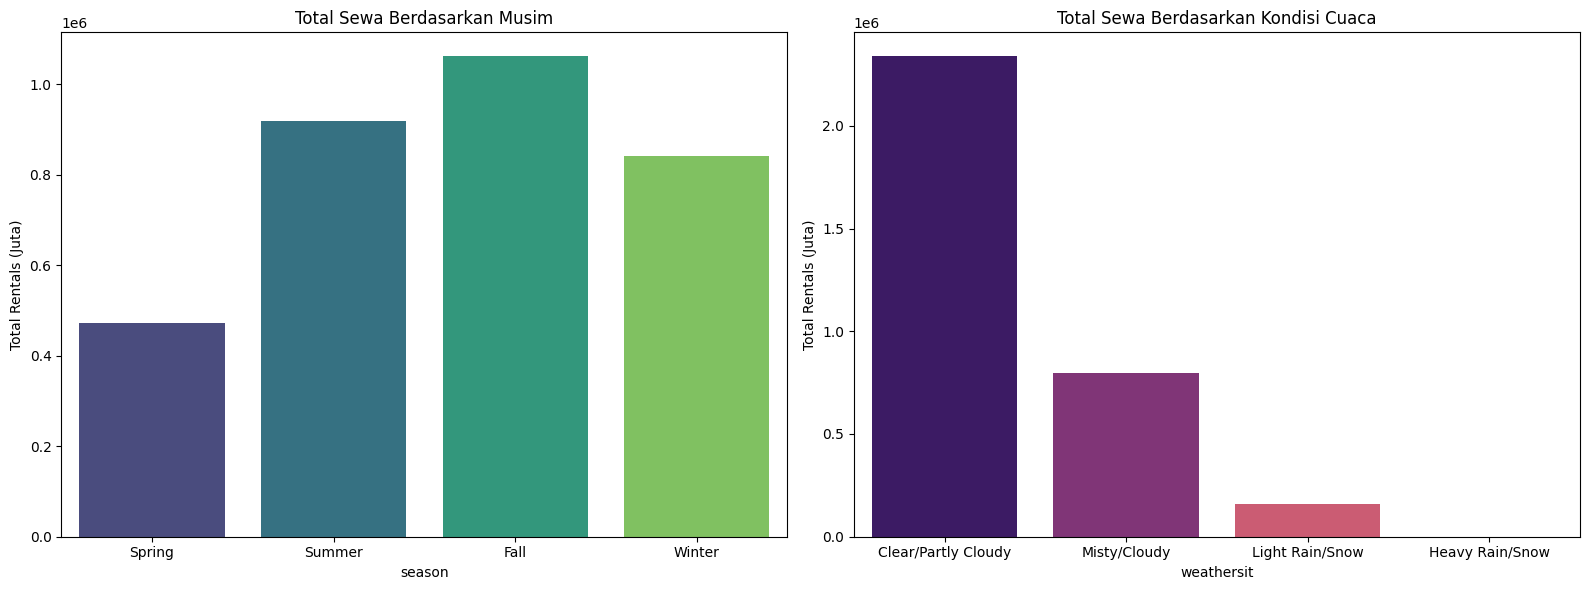

In [45]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.barplot(
    data=day_df,
    x='season',
    y='total_rentals',
    hue='season',
    estimator="sum",
    ax=ax[0],
    palette='viridis',
    legend=False,
    errorbar=None
)
ax[0].set_title('Total Sewa Berdasarkan Musim')
ax[0].set_ylabel('Total Rentals (Juta)')

sns.barplot(
    data=hour_df,
    x='weathersit',
    y='total_rentals',
    hue='weathersit',
    estimator="sum",
    ax=ax[1],
    palette='magma',
    legend=False,
    errorbar=None
)
ax[1].set_title('Total Sewa Berdasarkan Kondisi Cuaca')
ax[1].set_ylabel('Total Rentals (Juta)')

plt.tight_layout()
plt.show()

**Insight:**
1. pada grafik Musim, terlihat Fall mencapai angka di atas 1.0 Juta.
2. pada grafik Cuaca, terlihat Clear (Cuaca Cerah) mendominasi dengan angka yang juga menembus jutaan, jauh meninggalkan cuaca buruk.

### Pertanyaan 3: Bagaimana perbandingan karakteristik dan tren antara pengguna Casual dan Registered dalam melakukan penyewaan?

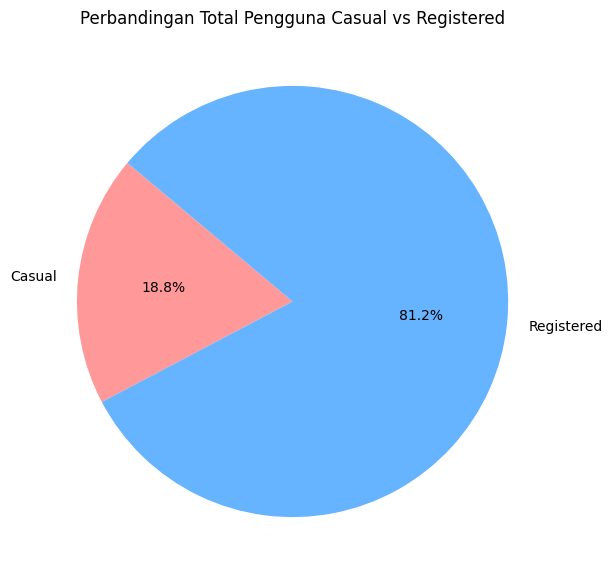

In [35]:
labels = ['Casual', 'Registered']
sizes = [hour_df['casual_users'].sum(), hour_df['registered_users'].sum()]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Perbandingan Total Pengguna Casual vs Registered')
plt.show()

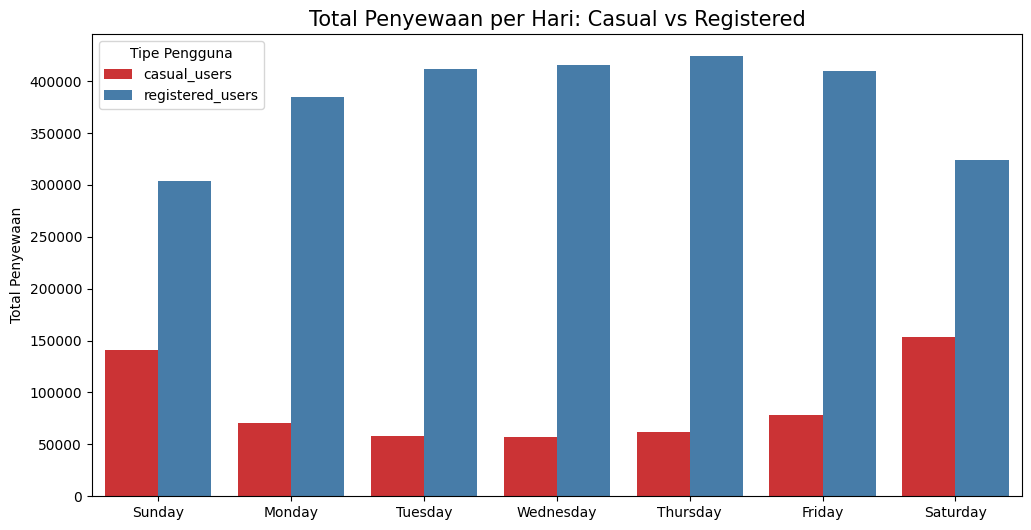

In [36]:
daily_user_df = hour_df.groupby('weekday', observed=True)[['casual_users', 'registered_users']].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=pd.melt(daily_user_df, id_vars='weekday'),
            x='weekday',
            y='value',
            hue='variable',
            palette='Set1'
)

plt.title('Total Penyewaan per Hari: Casual vs Registered', fontsize=15)
plt.xlabel(None)
plt.ylabel('Total Penyewaan')
plt.legend(title='Tipe Pengguna')
plt.show()

**Insight:**

Pada setiap harinya, registered users konsisten terus melakukan penyewaan. Sedangkan casual users lebih banyak melakukan penyewaan saat weekend

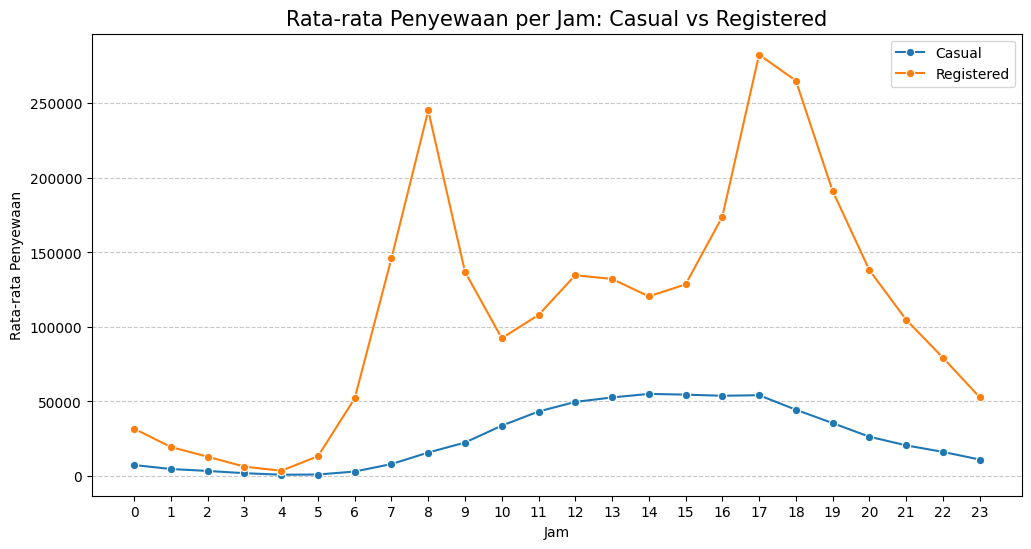

In [37]:
hourly_user_df = hour_df.groupby('hour')[['casual_users', 'registered_users']].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_user_df, x='hour', y='casual_users', label='Casual', marker='o')
sns.lineplot(data=hourly_user_df, x='hour', y='registered_users', label='Registered', marker='o')

plt.title('Rata-rata Penyewaan per Jam: Casual vs Registered', fontsize=15)
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [47]:
day_df.to_csv("day.csv", index=False)

In [48]:
hour_df.to_csv("hour.csv", index=False)

**Insight:**

Dapat dilihat bahwa registered users biasanya banyak melakukan penyewaan di jam sibuk, sedangkan casual users cenderung meningkat secara perlahan mulai siang hari dan stabil di sore hari

### Pertanyaan 4: Apakah terdapat perbedaan signifikan pada pola penyewaan antara hari kerja (workingday) dibandingkan dengan hari libur (holiday/weekend)?

In [38]:
result = day_df.groupby(by="workingday").total_rentals.sum().reset_index()
print(result)

   workingday  total_rentals
0           0        1000269
1           1        2292410


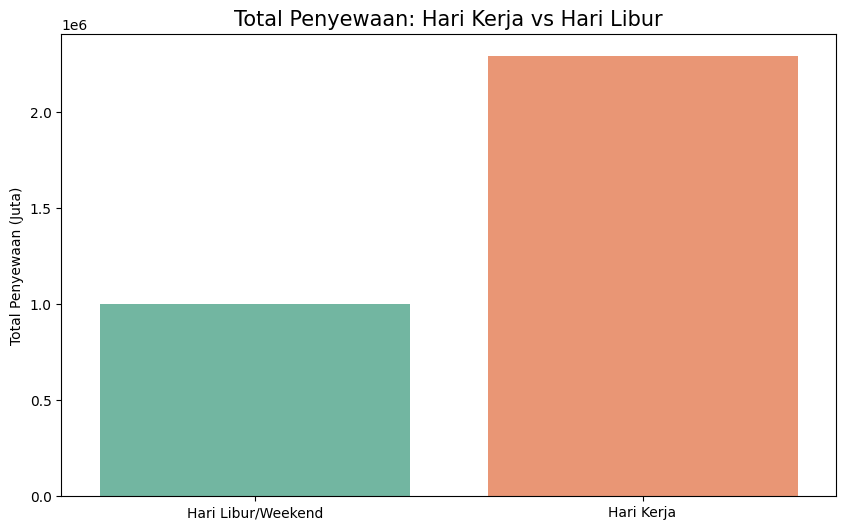

In [39]:
workingday_rentals = hour_df.groupby('workingday')['total_rentals'].sum().reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=workingday_rentals,
    x='workingday',
    y='total_rentals',
    hue='workingday',
    estimator='sum',
    palette='Set2',
    legend=False,
    errorbar=None
)

plt.xticks([0, 1], ['Hari Libur/Weekend', 'Hari Kerja'])
plt.title('Total Penyewaan: Hari Kerja vs Hari Libur', fontsize=15)
plt.ylabel('Total Penyewaan (Juta)')
plt.xlabel(None)
plt.show()

**Insight:**
penyawaan lebih banyak terjadi di hari kerja

## Conclusion

1. Bagaimana perubahan jumlah penyewaan sepeda berdasarkan siklus waktu (jam, hari dalam seminggu, bulan, dan tahun)?Conclusion: Penyewaan tahun 2012 jauh meningkat dibandingkan pada tahun 2011. Jumlah penyewaan sepeda terbanyak terjadi pada momen-momen tertentu, seperti: jam sibuk dan bulan saat musim gugur.

2. Sejauh mana faktor lingkungan (musim dan cuaca) memengaruhi total volume penyewaan sepeda? Conclusion: Sangat berpengaruh. Karena Fall/musim gugur dan cuaca cerah/sebagian berawan menjadi saat yang digemari sehingga penyewaan meningkat.
3. Bagaimana perbandingan karakteristik dan tren antara pengguna Casual dan Registered dalam melakukan penyewaan? Conclusion: pengguna casual relatif melakukan penyewaan bergantung pada jam/cuaca/musim, sedangkan registered user konsisten melakukan penyewaan terutama di jam sibuk
4. Apakah terdapat perbedaan signifikan pada pola penyewaan antara hari kerja (workingday) dibandingkan dengan hari libur (holiday/weekend)? Conclusion: Ya. penyewaan terbanyak terjadi pada hari kerja.


## Analisis Lanjutan (Opsional)

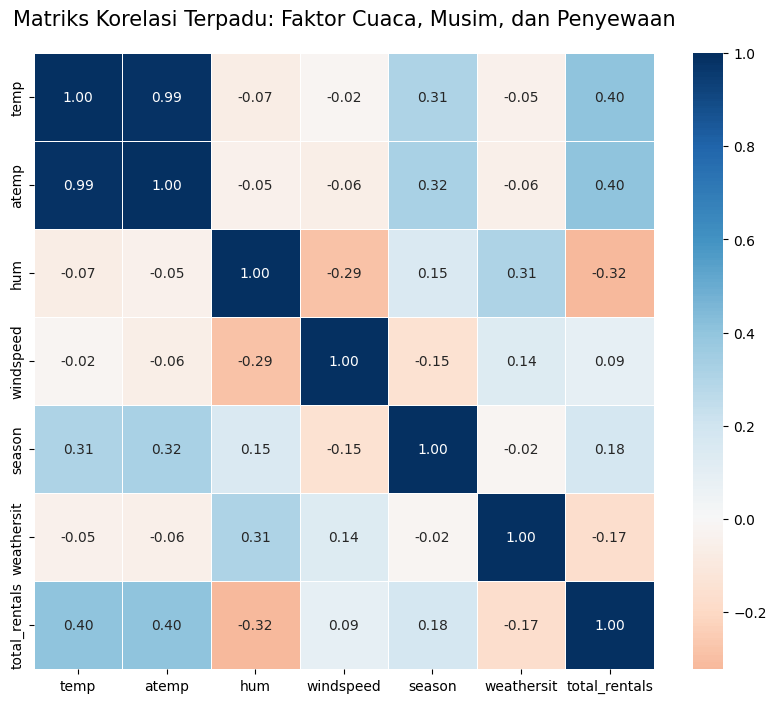

In [40]:
cols_to_corr = ['temp', 'atemp', 'hum', 'windspeed', 'season', 'weathersit', 'total_rentals']

temp_df = hour_df.copy()

if temp_df['season'].dtype == 'object' or temp_df['season'].dtype.name == 'category':
    season_map = {'Spring': 1, 'Summer': 2, 'Fall': 3, 'Winter': 4}
    temp_df['season'] = temp_df['season'].map(season_map)

if temp_df['weathersit'].dtype == 'object' or temp_df['weathersit'].dtype.name == 'category':
    weather_map = {'Clear': 1, 'Misty/Cloudy': 2, 'Light Rain/Snow': 3, 'Heavy Rain/Snow': 4}
    temp_df['weathersit'] = temp_df['weathersit'].map(weather_map)

correlation_matrix = temp_df[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='RdBu',
    fmt=".2f",
    center=0,
    linewidths=0.5
)

plt.title("Matriks Korelasi Terpadu: Faktor Cuaca, Musim, dan Penyewaan", fontsize=15, pad=20)
plt.show()

Temporal RFM Analysis (Monthly)

Top 5 Months by Monetary (Total Rentals):


,month,max_date,frequency,monetary,recency
7,Agustus,2012-08-31,1475,351194,122
5,Juni,2012-06-30,1440,346342,184
8,September,2012-09-30,1437,345991,92
6,Juli,2012-07-31,1488,344948,153
4,Mei,2012-05-31,1488,331686,214



Top 5 Months by Recency (Most Recent):


,month,max_date,frequency,monetary,recency
11,Desember,2012-12-31,1483,211036,0
10,November,2012-11-30,1437,254831,31
9,Oktober,2012-10-31,1451,322352,61
8,September,2012-09-30,1437,345991,92
7,Agustus,2012-08-31,1475,351194,122


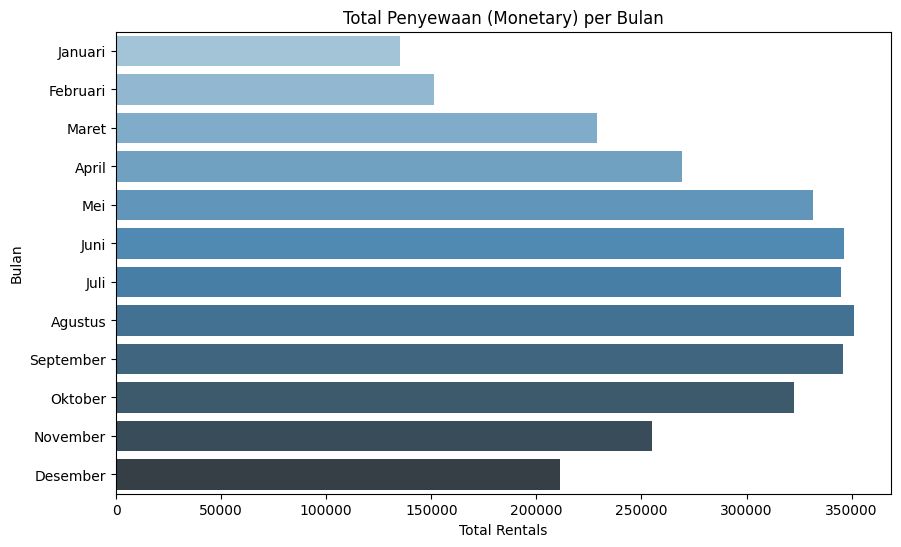

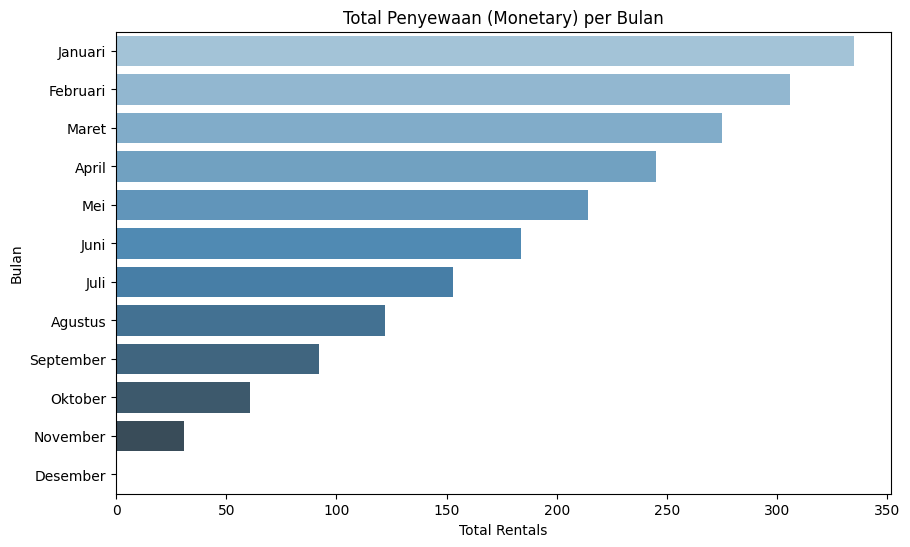

In [41]:
rfm_df = hour_df.groupby(by="month", sort=False, observed=True).agg({
    "date": "max",        #Untuk Recency (melihat tanggal terakhir di bulan itu)
    "total_rentals": ["count", "sum"] #count untuk Frequency, sum untuk Monetary
}).reset_index()

#merapikan nama kolom hasil agregasi
rfm_df.columns = ["month", "max_date", "frequency", "monetary"]

#menghitung Recency (Jarak hari dari tanggal terakhir dataset)
recent_date = hour_df["date"].max()
rfm_df["recency"] = (recent_date - rfm_df["max_date"]).dt.days

print("Temporal RFM Analysis (Monthly)")

# Menampilkan Tabel Top 5 secara berdampingan
print("\nTop 5 Months by Monetary (Total Rentals):")
display(rfm_df.sort_values(by="monetary", ascending=False).head(5))

print("\nTop 5 Months by Recency (Most Recent):")
display(rfm_df.sort_values(by="recency", ascending=True).head(5))

# Visualisasi RFM: Monetary
plt.figure(figsize=(10, 6))
sns.barplot(
    y="month",
    x="monetary",
    data=rfm_df.sort_values(by="monetary", ascending=False),
    palette="Blues_d",
    hue="month",
    legend=False
)
plt.title("Total Penyewaan (Monetary) per Bulan")
plt.xlabel("Total Rentals")
plt.ylabel("Bulan")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    y="month",
    x="recency",
    data=rfm_df.sort_values(by="monetary", ascending=False),
    palette="Blues_d",
    hue="month",
    legend=False
)
plt.title("Total Penyewaan (Monetary) per Bulan")
plt.xlabel("Total Rentals")
plt.ylabel("Bulan")
plt.show()

Karena tidak ada ID pengguna unik, maka dibuatlah versi modifikasi yakni Temporal RFM untuk melihat performa bisnis dari waktu ke waktu (bulan ke bulan).

Recency: mlihat kapan terakhir kali performa puncak terjadi.
Frequency: melihat seberapa stabil aktivitas penyewaan dalam satu bulan.
Monetary: melihat total volume penyewaan (pendapatan/omzet).

Insight: bulan September bisa menjadi puncak Monetary (bulan emas, karena High Monetary, Low Recency).

